In [70]:
import os
from dotenv import load_dotenv
from typing_extensions import TypedDict
from langchain_groq import ChatGroq
from langchain_community.tools import TavilySearchResults
from langchain_community.utilities import WikipediaAPIWrapper
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display


load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')


In [71]:
llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)

In [72]:
#state
class ResearchState(TypedDict):
    topic:str  #receive input queries
    research_plan : str #output of planner
    web_search : str #output of web search
    wiki_search : str #output of wiki search
    analysis : str #output of analyst node
    final_report: str #output of report generation node

In [73]:
#node 1 planner

def research_planner(state:ResearchState):
    """This is to plan the research for the given query"""
    topic = state["topic"]

    prompt = f"""You are a research planner, given the topic below, generate:

    1. Web search - extract concise summary from credible web sources, factual data,latest trends.
    2. Wiki search - extract the info from wiki sources.

    Return only 2 queries clearly labelled.

    Topic:{topic}
"""
    response = llm.invoke(prompt)
    return {"research_plan":response.content}

In [74]:
#node 2 web_serch

def web_searcher(state:ResearchState):
    """This is to search the web and extract the info from web"""
    topic = state["topic"]
    plan = state["research_plan"]

    tavily_search = TavilySearchResults(max_results=3)

    web_results = tavily_search.invoke(topic)

    prompt="""Summarize the below web results, for the given {topic}, keep 3 to 4
    bullet points, based on the given Research plan. 
    Research plan:{plan}
    Web Results:{web_results}
    """
    response = llm.invoke(prompt)
    return {"web_search":response.content}

In [75]:
#node 3 wiki search
def wiki_searcher(state:ResearchState):
    """This is to search the topic from wiki"""
    topic = state["topic"]
    plan = state["research_plan"]

    wiki_search = WikipediaAPIWrapper(top_k_results=3,doc_content_chars_max=2000)

    wiki_results = wiki_search.run(topic)

    prompt="""Summarize the below contents from wiki results for the given {topic},
    based on the given Research plan
    Research plan:{plan}
    Wiki Results: {wiki_results}
    """
    response = llm.invoke(prompt)
    return {"wiki_search":response.content}

In [ ]:
#node 3 analyst

def analyst(state:ResearchState):
    """This is an analyst node to analyze the results from different sources"""
    topic = state["topic"]
    web_ser = state["web_search"]
    wiki_ser = state["wiki_search"]

    prompt = """You are a Senior Analyst.
              Summarize the key findings from all the sources for the {topic} and provide the following points:
              Sources:
              1. Web results:{web_ser}
              2. Wiki resukts:{wiki_ser}

              Tasks:
              1. From the above sources, Identify the key trends or patterns,compare the key findings between sources.
              2. Present the sales performance data to highlight the crucial insights effectively.
              3. Identify the key competitors and the market share and the revenue model.
              4. Identify bottlenecks and inefficiencies and provide the data. 
             """
    response = llm.invoke(prompt)
    return {"analysis":response.content}

In [77]:
#node 5 report_generation

def report_generator(state:ResearchState):
    """This is a report generation node"""
    topic  = state["topic"]
    analysis = state["analysis"]

    prompt="""Generate a detailed report for the analysis given below for the {topic}:
          
            Analysis:{analysis}

            Based on the given analysis, generate a detailed report in below format:

            **Title :** Research on {topic}
            **Executive Summary :** A brief summary of analysis provided.
            **Key Findings:** Mention the findings from the analysis.
            **Comparisons:** If this is necessary then provide a comparison.
            **Conclusion** Final conclusion
           """
    response = llm.invoke(prompt)
    return {"final_report":response.content}

In [78]:
#graph construction

builder = StateGraph(ResearchState)

#nodes

builder.add_node("research_planner", research_planner)
builder.add_node("web_searcher",web_searcher)
builder.add_node("wiki_searcher", wiki_searcher)
builder.add_node("analyst",analyst)
builder.add_node("report_generator", report_generator)

#edges

builder.add_edge(START,"research_planner")
builder.add_edge("research_planner","web_searcher")
builder.add_edge("research_planner","wiki_searcher")
builder.add_edge("web_searcher","analyst")
builder.add_edge("wiki_searcher","analyst")
builder.add_edge("analyst","report_generator")
builder.add_edge("report_generator",END)



In [79]:
#compilation of graph

graph = builder.compile()

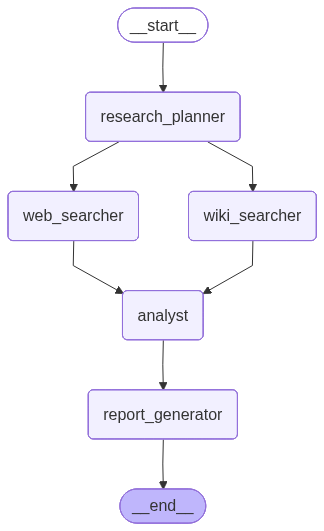

In [80]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [81]:
#results
query ="EV market comparison between India and USA"

results = graph.invoke({"topic": query})

In [82]:
print(results["final_report"])

However, I don't see any analysis provided. Please provide the analysis for the topic you'd like me to generate a report on, and I'll create a detailed report in the specified format.

Once you provide the analysis, I'll create a report that includes:

1. **Title :** Research on {topic}
2. **Executive Summary :** A brief summary of the analysis provided.
3. **Key Findings:** The findings from the analysis.
4. **Comparisons:** If necessary, a comparison of the findings.
5. **Conclusion:** The final conclusion based on the analysis.

Please provide the analysis, and I'll get started on the report.
